In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [4]:
BASE = "/kaggle/input/notebooks/krishnaiiith"

In [9]:
X = np.load(f"{BASE}/05-proposed-model/multimodal_features.npy")
y = np.load(f"{BASE}/05-proposed-model/multimodal_labels.npy")

print("MVSA samples:", len(y))

MVSA samples: 11902


In [12]:
with open(f"{BASE}/05-proposed-model/xgb_multimodal_model.pkl", "rb") as f:
    model = pickle.load(f)

print("Model loaded successfully")

Model loaded successfully


In [13]:
y_prob_mvsa = model.predict_proba(X)[:,1]
y_pred_mvsa = (y_prob_mvsa > 0.5).astype(int)

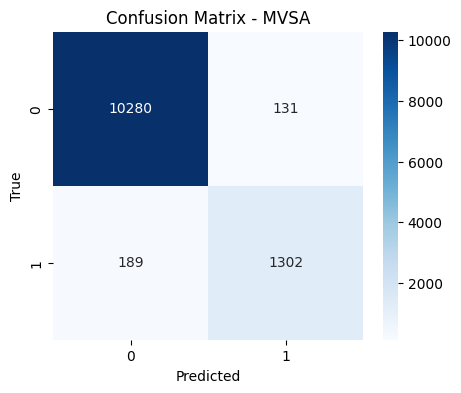

In [14]:
cm_mvsa = confusion_matrix(y, y_pred_mvsa)

plt.figure(figsize=(5,4))
sns.heatmap(cm_mvsa, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - MVSA")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [15]:
print("MVSA Classification Report")

print(
    classification_report(
        y,
        y_pred_mvsa,
        target_names=["Negative","Positive"]
    )
)

MVSA Classification Report
              precision    recall  f1-score   support

    Negative       0.98      0.99      0.98     10411
    Positive       0.91      0.87      0.89      1491

    accuracy                           0.97     11902
   macro avg       0.95      0.93      0.94     11902
weighted avg       0.97      0.97      0.97     11902



In [17]:
y_pred_hateful = np.load(
    f"{BASE}/08-cross-dataset-valuation/hateful_y_pred.npy"
)

y_prob_hateful = np.load(
    f"{BASE}/08-cross-dataset-valuation/hateful_y_prob.npy"
)

y_test_hateful = np.load(
    f"{BASE}/08-cross-dataset-valuation/hateful_y_test.npy"
)

print("Hateful memes samples:", len(y_test_hateful))

Hateful memes samples: 1700


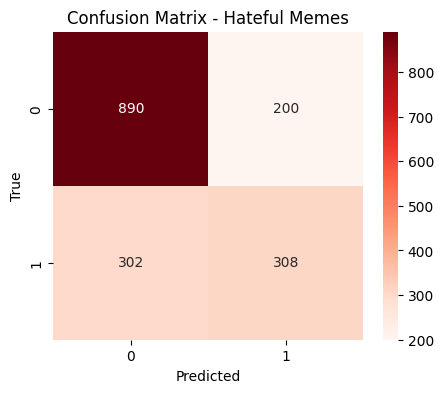

In [18]:
cm_hateful = confusion_matrix(
    y_test_hateful,
    y_pred_hateful
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_hateful,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("Confusion Matrix - Hateful Memes")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [20]:
# MVSA

fpr_mvsa, tpr_mvsa, _ = roc_curve(y, y_prob_mvsa)
auc_mvsa = roc_auc_score(y, y_prob_mvsa)


# Hateful Memes

fpr_hm, tpr_hm, _ = roc_curve(
    y_test_hateful,
    y_prob_hateful
)

auc_hm = roc_auc_score(
    y_test_hateful,
    y_prob_hateful
)

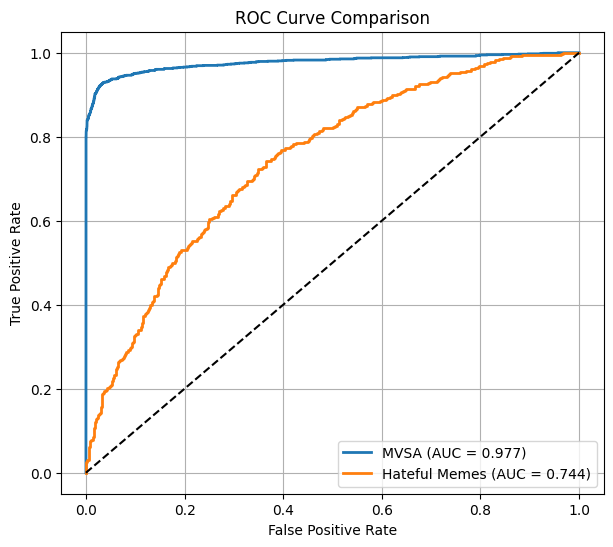

In [21]:
plt.figure(figsize=(7,6))

plt.plot(
    fpr_mvsa,
    tpr_mvsa,
    label=f"MVSA (AUC = {auc_mvsa:.3f})",
    linewidth=2
)

plt.plot(
    fpr_hm,
    tpr_hm,
    label=f"Hateful Memes (AUC = {auc_hm:.3f})",
    linewidth=2
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

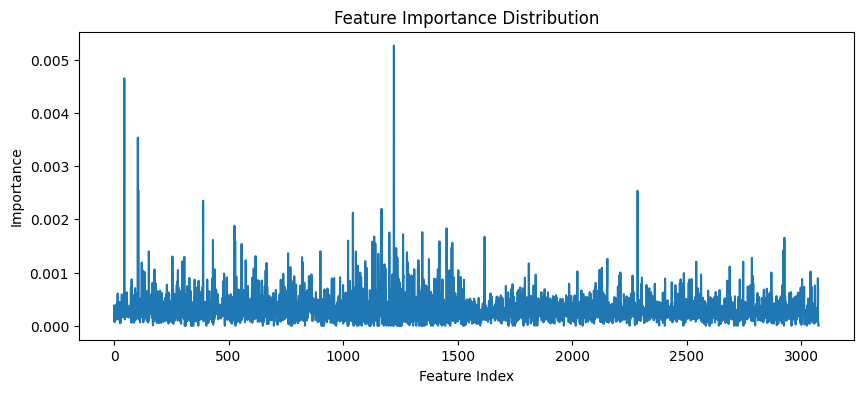

In [22]:
importances = model.feature_importances_

plt.figure(figsize=(10,4))

plt.plot(importances)

plt.title("Feature Importance Distribution")
plt.xlabel("Feature Index")
plt.ylabel("Importance")

plt.show()

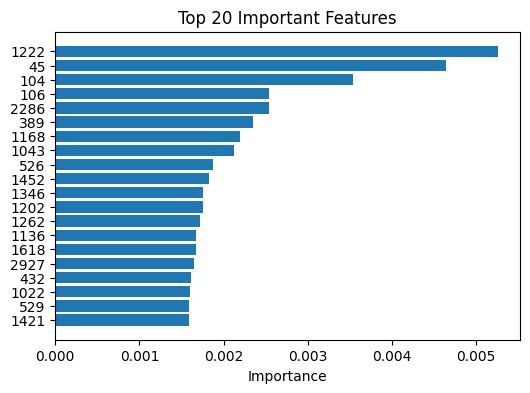

In [23]:
top_idx = np.argsort(importances)[-20:]

plt.figure(figsize=(6,4))

plt.barh(range(20), importances[top_idx])

plt.yticks(range(20), top_idx)

plt.title("Top 20 Important Features")

plt.xlabel("Importance")

plt.show()

In [24]:
results = pd.DataFrame({

    "Dataset":[
        "MVSA",
        "Hateful Memes"
    ],

    "Samples":[
        len(y),
        len(y_test_hateful)
    ],

    "ROC-AUC":[
        auc_mvsa,
        auc_hm
    ]

})

results

,Dataset,Samples,ROC-AUC
0,MVSA,11902,0.977291
1,Hateful Memes,1700,0.744273


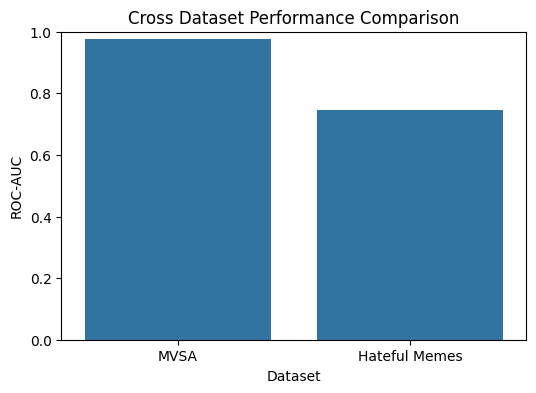

In [25]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Dataset",
    y="ROC-AUC",
    data=results
)

plt.title("Cross Dataset Performance Comparison")

plt.ylim(0,1)

plt.show()

In [27]:
mvsa_test = pd.read_csv(
    f"{BASE}/05-proposed-model/test_predictions.csv"
)

mvsa_test.head()

,true_label,pred_label,probability
0,0,0,0.011041
1,0,0,0.028531
2,0,0,0.021236
3,0,0,0.003755
4,0,0,0.004758


In [29]:
print(mvsa_test.columns)

Index(['true_label', 'pred_label', 'probability'], dtype='object')


In [30]:
y_test_mvsa = mvsa_test["true_label"]
y_prob_mvsa_test = mvsa_test["probability"]

auc_mvsa_test = roc_auc_score(
    y_test_mvsa,
    y_prob_mvsa_test
)

print("MVSA Test ROC-AUC:", auc_mvsa_test)

MVSA Test ROC-AUC: 0.8230989441532119


In [31]:
results = pd.DataFrame({

    "Dataset":[
        "MVSA Test",
        "Hateful Memes"
    ],

    "Samples":[
        len(y_test_mvsa),
        len(y_test_hateful)
    ],

    "ROC-AUC":[
        auc_mvsa_test,
        auc_hm
    ]

})

results

,Dataset,Samples,ROC-AUC
0,MVSA Test,2381,0.823099
1,Hateful Memes,1700,0.744273


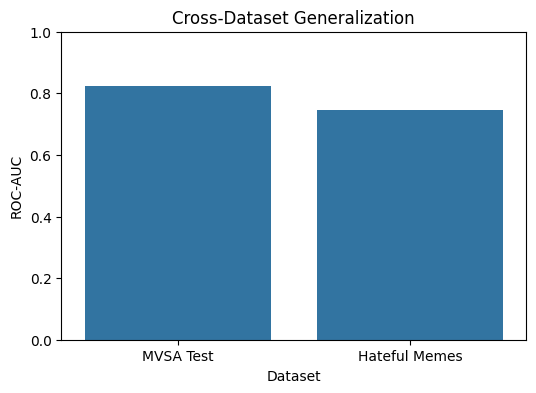

In [32]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Dataset",
    y="ROC-AUC",
    data=results
)

plt.title("Cross-Dataset Generalization")

plt.ylim(0,1)

plt.ylabel("ROC-AUC")

plt.show()

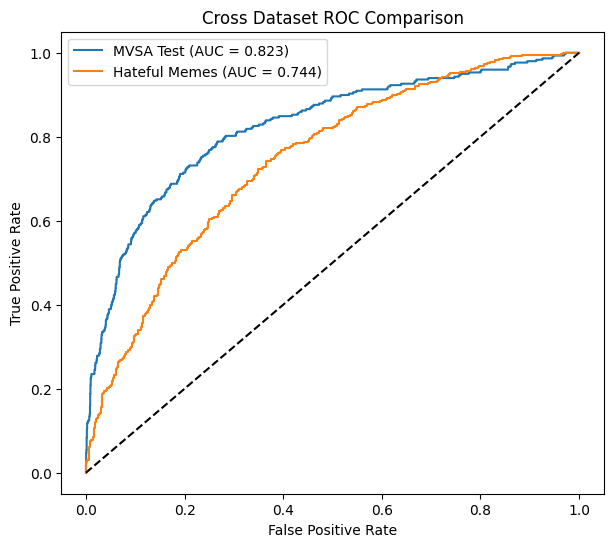

In [33]:
fpr_mvsa_test, tpr_mvsa_test, _ = roc_curve(
    y_test_mvsa,
    y_prob_mvsa_test
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr_mvsa_test,
    tpr_mvsa_test,
    label=f"MVSA Test (AUC = {auc_mvsa_test:.3f})"
)

plt.plot(
    fpr_hm,
    tpr_hm,
    label=f"Hateful Memes (AUC = {auc_hm:.3f})"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Cross Dataset ROC Comparison")

plt.legend()

plt.show()